In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np
import os

from milliontrees.datasets.TreePolygons import TreePolygonsDataset


In [12]:
class TreePolygonsBinaryDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        metadata, image, targets = self.base[idx]

        instance_masks = targets["y"]  # [N, H, W]
        binary_mask = instance_masks.any(dim=0).long()  # [H, W]

        return image, binary_mask


In [3]:

#dataset = TreePolygonsDataset(
#    root_dir="./data",
#    download=True,
#    mini=True,
#    split_scheme="random",
#)

train_full = dataset.get_subset("train")
test_ds = dataset.get_subset("test")

# split train → train/val
n_train = int(0.8 * len(train_full))
n_val = len(train_full) - n_train

train_ds, val_ds = random_split(
    train_full,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

# wrap binary
train_ds = TreePolygonsBinaryDataset(train_ds)
val_ds = TreePolygonsBinaryDataset(val_ds)
test_ds = TreePolygonsBinaryDataset(test_ds)


  0%|                                      | 129564672/106085316699 [01:06<15:06:39, 1947734.88Byte/s]


Extracting ./data/TreePolygons_v0.10/archive.zip to ./data/TreePolygons_v0.10

It took 1.11 minutes to download and uncompress the dataset.



In [4]:
BATCH_SIZE = 8

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)


In [5]:

class DinoV2Segmentation(nn.Module):
    def __init__(self, backbone, feat_dim=384):
        super().__init__()
        self.backbone = backbone

        self.decoder = nn.Sequential(
            nn.Conv2d(feat_dim, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 2, kernel_size=1)
        )

    def forward(self, x):
        feats = self.backbone.forward_features(x)
        patch_tokens = feats["x_norm_patchtokens"]

        B, N, C = patch_tokens.shape
        H = W = int(N ** 0.5)

        feat_map = patch_tokens.permute(0, 2, 1).reshape(B, C, H, W)

        logits = self.decoder(feat_map)
        logits = F.interpolate(logits, size=(448, 448), mode="bilinear", align_corners=False)

        return logits


## Load DINOv2

In [6]:

backbone = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")

for param in backbone.parameters():
    param.requires_grad = False


Using cache found in /Users/zahra/.cache/torch/hub/facebookresearch_dinov2_main
/Users/zahra/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/zahra/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/zahra/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


## Training setup

In [7]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DinoV2Segmentation(backbone).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)


In [8]:

def train_segmentation(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler, device, epochs
):
    history = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, masks)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        scheduler.step()

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                logits = model(images)
                loss = criterion(logits, masks)

                val_loss += loss.item()

        print(f"Epoch {epoch+1} | train {train_loss:.4f} | val {val_loss:.4f}")

        history.append({
            "train_loss": train_loss,
            "val_loss": val_loss
        })

    return history


In [9]:

history = train_segmentation(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs=15
)


Epoch 1 | train 10.1448 | val 3.9307
Epoch 2 | train 2.5864 | val 0.7360
Epoch 3 | train 1.7164 | val 0.7752
Epoch 4 | train 1.0622 | val 0.7308
Epoch 5 | train 1.5387 | val 0.6889
Epoch 6 | train 0.9123 | val 0.6804
Epoch 7 | train 0.8838 | val 0.6800
Epoch 8 | train 1.2499 | val 0.6797
Epoch 9 | train 1.2388 | val 0.6793
Epoch 10 | train 1.2185 | val 0.6790
Epoch 11 | train 1.2065 | val 0.6790
Epoch 12 | train 1.1992 | val 0.6792
Epoch 13 | train 1.2264 | val 0.6795
Epoch 14 | train 1.2231 | val 0.6800
Epoch 15 | train 1.1605 | val 0.6812


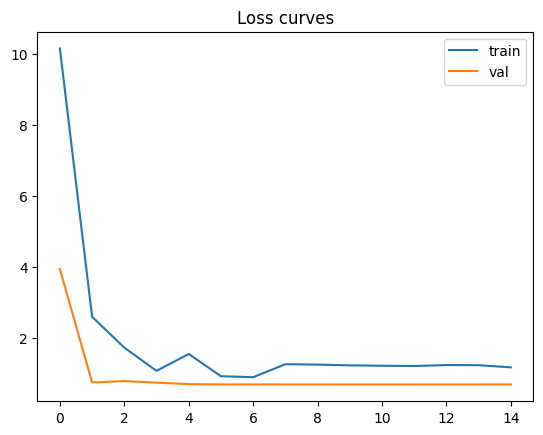

In [10]:

train_losses = [h["train_loss"] for h in history]
val_losses = [h["val_loss"] for h in history]

plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.legend()
plt.title("Loss curves")
plt.show()


In [11]:

os.makedirs("runs/dinov2_segmentation", exist_ok=True)

torch.save(
    model.state_dict(),
    "runs/dinov2_segmentation/best_model_dinov2_segmentation.pth"
)
